In [1]:
import numpy as np
import itertools
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import Aer
from qiskit import transpile


In [2]:
returns = np.array([0.12, 0.18, 0.10, 0.15])
lambda_risk = 0.5

cov = np.array([
    [0.10, 0.02, 0.01, 0.03],
    [0.02, 0.08, 0.02, 0.01],
    [0.01, 0.02, 0.09, 0.02],
    [0.03, 0.01, 0.02, 0.07]
])

def portfolio_objective(x, risk_matrix):
    return np.dot(returns, x) - lambda_risk * np.dot(x, np.dot(risk_matrix, x))

best_score = -1e9
best_portfolio = None

for comb in itertools.product([0,1], repeat=4):
    if sum(comb) == 2:
        x = np.array(comb)
        score = portfolio_objective(x, cov)
        if score > best_score:
            best_score = score
            best_portfolio = x

print("Classical Best Portfolio:", best_portfolio)
print("Classical Best Score:", best_score)

Classical Best Portfolio: [0 1 0 1]
Classical Best Score: 0.24499999999999997


In [3]:
features = np.array([
    [0.12, 0.10],
    [0.18, 0.08],
    [0.10, 0.09],
    [0.15, 0.07]
])

def quantum_state(x):
    qc = QuantumCircuit(2)
    qc.ry(x[0], 0)
    qc.ry(x[1], 1)
    return Statevector.from_instruction(qc)

quantum_kernel_matrix = np.zeros((4,4))

for i in range(4):
    for j in range(4):
        psi_i = quantum_state(features[i])
        psi_j = quantum_state(features[j])
        overlap = np.abs(np.vdot(psi_i.data, psi_j.data))**2
        quantum_kernel_matrix[i][j] = overlap

print("\nQuantum Kernel Matrix:")
print(quantum_kernel_matrix)




Quantum Kernel Matrix:
[[1.         0.99900036 0.99987501 0.99955008]
 [0.99900036 1.         0.99837589 0.99975002]
 [0.99987501 0.99837589 1.         0.9992752 ]
 [0.99955008 0.99975002 0.9992752  1.        ]]


In [4]:
def create_qaoa_circuit(gamma, beta, Q):
    n = 4
    qc = QuantumCircuit(n, n)

    # Initial superposition
    for i in range(n):
        qc.h(i)

    # Cost Hamiltonian (RZZ interactions)
    for i in range(n):
        for j in range(i+1, n):   # <-- FIX HERE
            if Q[i][j] != 0:
                qc.rzz(2 * gamma * Q[i][j], i, j)


    # Mixer
    for i in range(n):
        qc.rx(2 * beta, i)

    qc.measure(range(n), range(n))
    return qc
    

In [5]:
Q = np.zeros((4,4))
for i in range(4):
    Q[i][i] += returns[i]
    for j in range(4):
        Q[i][j] -= lambda_risk * quantum_kernel_matrix[i][j]

gamma = 0.5
beta = 0.5

qc = create_qaoa_circuit(gamma, beta, Q)


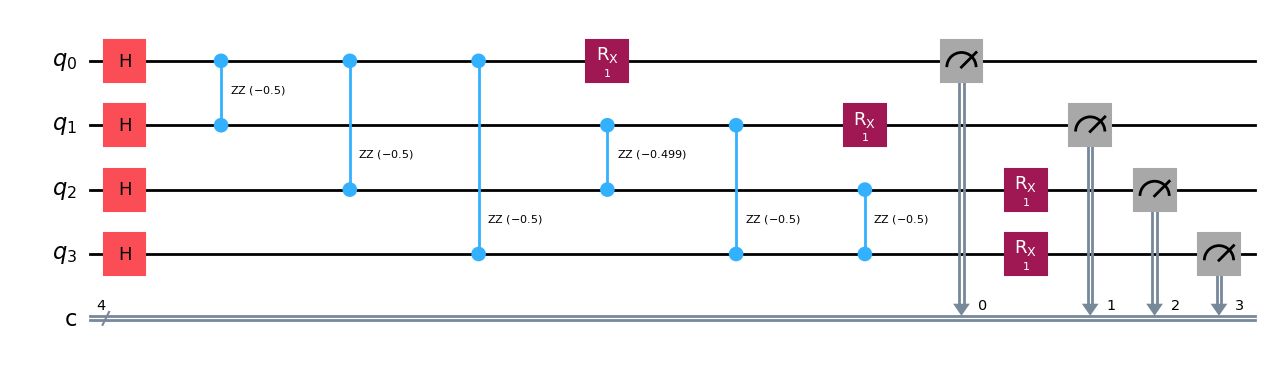

In [6]:
qc.draw('mpl')

In [7]:
backend = Aer.get_backend("qasm_simulator")
qc = transpile(qc, backend)

job = backend.run(qc, shots=2048)
result = job.result()
counts = result.get_counts()

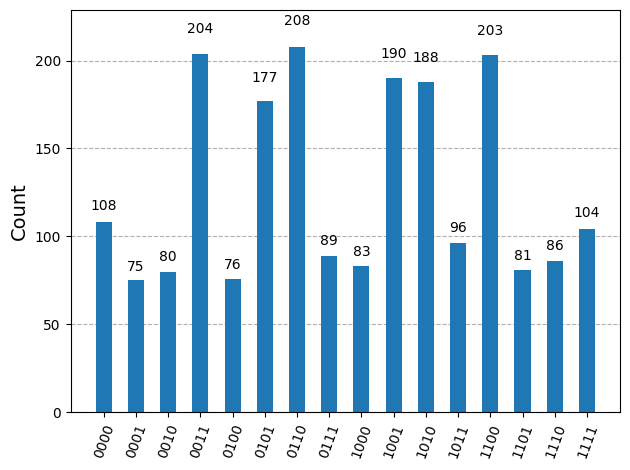

In [8]:
import matplotlib
from qiskit.visualization import plot_histogram

plot_histogram(counts)

In [9]:
valid_counts = {k: v for k, v in counts.items() if k.count("1") == 2}


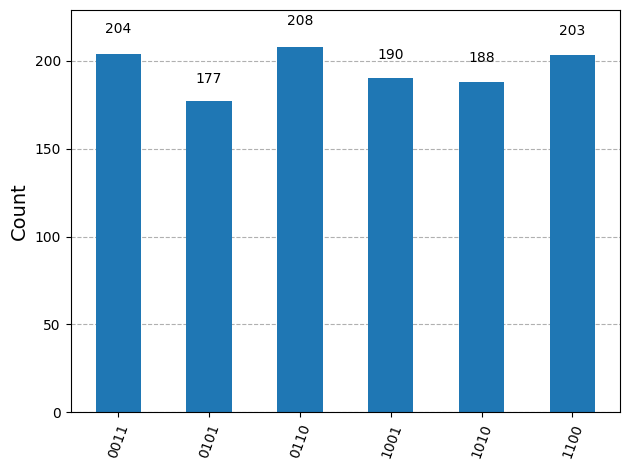

In [10]:
plot_histogram(valid_counts)

In [11]:
best_qaoa = max(valid_counts, key=valid_counts.get)

In [13]:
print(best_qaoa)

0110
